In [1]:
#import the libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

In [2]:
df=pd.read_csv('usinflation.csv')

In [3]:
df.head()

,year,month,inflation_1
0,1950,2,-3.552289
1,1950,3,5.247540
2,1950,4,1.692860
3,1950,5,5.064298
4,1950,6,6.719322


In [4]:
df['date']=pd.to_datetime(df[['year','month']].assign(day=1))

In [5]:
#set date as an index
df.set_index('date',inplace=True)

In [6]:
df.drop(columns=['year','month'],inplace=True)

In [7]:
df.head()

,inflation_1
date,
1950-02-01,-3.552289
1950-03-01,5.247540
1950-04-01,1.692860
1950-05-01,5.064298
1950-06-01,6.719322


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 491 entries, 1950-02-01 to 1990-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   inflation_1  491 non-null    float64
dtypes: float64(1)
memory usage: 7.7 KB


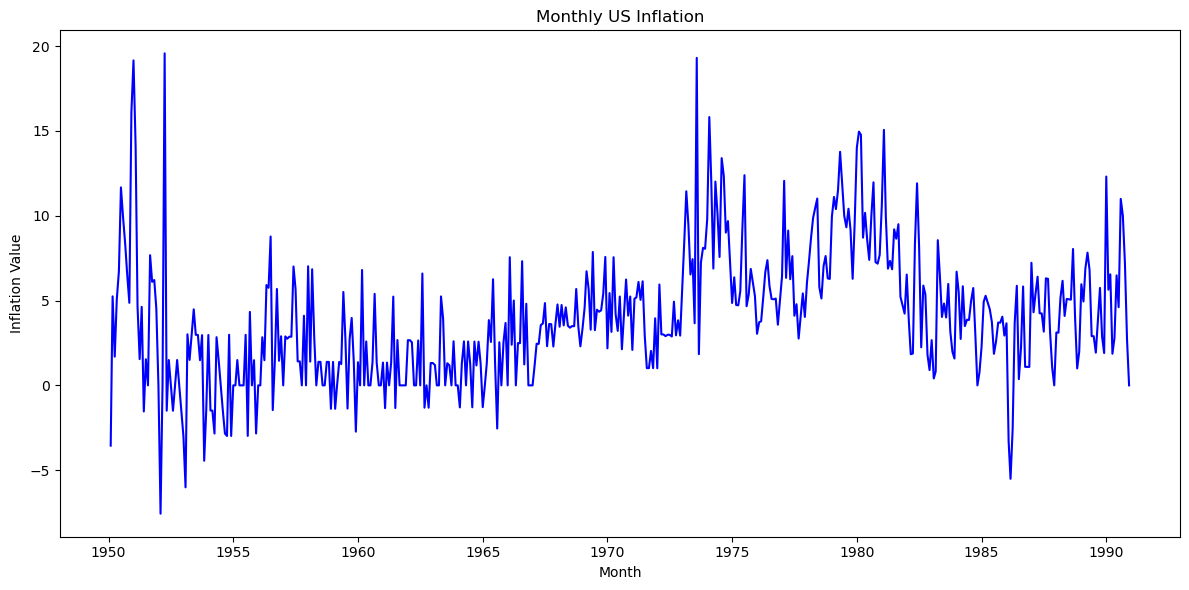

In [9]:
#plot the original time series:
plt.figure(figsize=(12,6))
plt.plot(df,label='Monthly US Inflation',color='blue')
plt.title('Monthly US Inflation')
plt.xlabel('Month')
plt.ylabel('Inflation Value')

plt.tight_layout()
plt.show()

In [10]:
#split into train and test
x=df[['inflation_1']]
size=int(len(x)*0.80)
train=x.iloc[0:size].copy()
test=x.iloc[size:len(x)].copy()

In [11]:
##Fit Baseline Models:

In [12]:
#Historical mean
hist_mean=np.mean(train['inflation_1'])
hist_mean

np.float64(4.032548522959183)

In [13]:
test.loc[:,'pred_mean']=hist_mean
test

,inflation_1,pred_mean
date,,
1982-10-01,5.358331,4.032549
1982-11-01,1.808168,4.032549
1982-12-01,0.903063,4.032549
1983-01-01,2.664138,4.032549
1983-02-01,0.409372,4.032549
...,...,...
1990-08-01,10.992540,4.032549
1990-09-01,9.988676,4.032549
1990-10-01,7.212614,4.032549


In [14]:
#MAPE function:
def mape(y_true,y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

In [15]:
mape_hist_mean=mape(test['inflation_1'],test['pred_mean'])
mape_hist_mean

np.float64(inf)

In [16]:
#MAPE becomes infinity because the actual value (y_true) contains zero, causing division by zero in the MAPE formula.

In [17]:
#mean_absolute_error
from sklearn.metrics import mean_absolute_error
mae_hist_mean=mean_absolute_error(test['inflation_1'],test['pred_mean'])
mae_hist_mean

2.046072067279942

In [18]:
#On average, the model’s predictions deviate from the actual inflation by about 2.05 units, indicating the typical magnitude of error.

In [19]:
# Last observation (from train set)
last_value = train['inflation_1'].iloc[-1]

# Assign this value as prediction for all test points
test['pred_last'] = last_value

In [20]:
test

,inflation_1,pred_mean,pred_last
date,,,
1982-10-01,5.358331,4.032549,5.880264
1982-11-01,1.808168,4.032549,5.880264
1982-12-01,0.903063,4.032549,5.880264
1983-01-01,2.664138,4.032549,5.880264
1983-02-01,0.409372,4.032549,5.880264
...,...,...,...
1990-08-01,10.992540,4.032549,5.880264
1990-09-01,9.988676,4.032549,5.880264
1990-10-01,7.212614,4.032549,5.880264


In [21]:
#mean_absolute_error
from sklearn.metrics import mean_absolute_error
mae_last=mean_absolute_error(test['inflation_1'],test['pred_last'])
mae_last

2.6158777676767677

In [22]:
#On average, the model’s predictions deviate from the actual inflation by about 2.61 units, indicating the typical magnitude of error.

In [23]:
##The historical mean model performs better than the naïve (last value) model, as it has a lower MAE (2.046 vs 2.615). This suggests that averaging past values provides more stable and accurate predictions than relying only on the most recent observation. Hence, for this dataset, the mean model is a better baseline.

In [24]:
#check stationarity of the data
r=adfuller(df['inflation_1'])
r

(np.float64(-2.489327106917803),
 np.float64(0.118092798418656),
 18,
 472,
 {'1%': np.float64(-3.444280551073031),
  '5%': np.float64(-2.867682902679315),
  '10%': np.float64(-2.5700419306592934)},
 np.float64(2302.9168398122083))

In [25]:
#Since the p-value (0.11) is greater than 0.05, we fail to reject the null hypothesis, indicating that the series is non-stationary.

In [26]:
#create a differenced series to make it sationary
def trend_differencing(dataset,interval=1):
    diff=list()
    for i in range(interval,len(dataset)):
        value=dataset[i]-dataset[i-interval]
        diff.append(value)
    return np.array(diff)

In [27]:
diff=trend_differencing(df['inflation_1'].values,interval=1)
diff

array([ 8.7998290e+00, -3.5546800e+00,  3.3714380e+00,  1.6550240e+00,
        4.9495980e+00, -1.7564190e+00, -1.5657150e+00, -1.8290200e+00,
       -1.6526810e+00,  1.1211236e+01,  3.0779190e+00, -5.0923300e+00,
       -9.4110960e+00, -3.1045040e+00,  3.0807000e+00, -6.1673650e+00,
        3.0807100e+00, -1.5403550e+00,  7.6722570e+00, -1.5696810e+00,
        1.0689600e-01, -1.6763200e+00, -4.5331520e+00, -7.5648660e+00,
        7.5648660e+00,  1.9570490e+01, -2.1064641e+01,  2.9883020e+00,
       -1.4941510e+00, -1.4941510e+00,  1.4941510e+00,  1.4941510e+00,
       -1.4941510e+00, -1.4941510e+00, -1.4997430e+00, -3.0163970e+00,
        9.0191990e+00, -1.5072780e+00,  1.4960040e+00,  1.4848230e+00,
       -1.5034280e+00, -7.4800000e-03, -1.4884780e+00,  1.4775840e+00,
       -7.4043810e+00,  2.9588200e+00,  4.4528840e+00, -4.4510490e+00,
       -1.8350000e-03, -1.3550000e+00,  5.6798120e+00, -1.3550000e+00,
       -1.4849060e+00, -1.4849060e+00, -1.3550000e+00, -1.4238500e-01,
      

In [28]:
r=adfuller(diff)
r

(np.float64(-5.94690656471536),
 np.float64(2.193240845643755e-07),
 18,
 471,
 {'1%': np.float64(-3.444310291143469),
  '5%': np.float64(-2.867695986993458),
  '10%': np.float64(-2.5700489042602586)},
 np.float64(2301.596788898526))

In [29]:
#Since the p-value is nearly zero after first differencing, the series becomes stationary, confirming that d = 1 is appropriate for the ARIMA model.

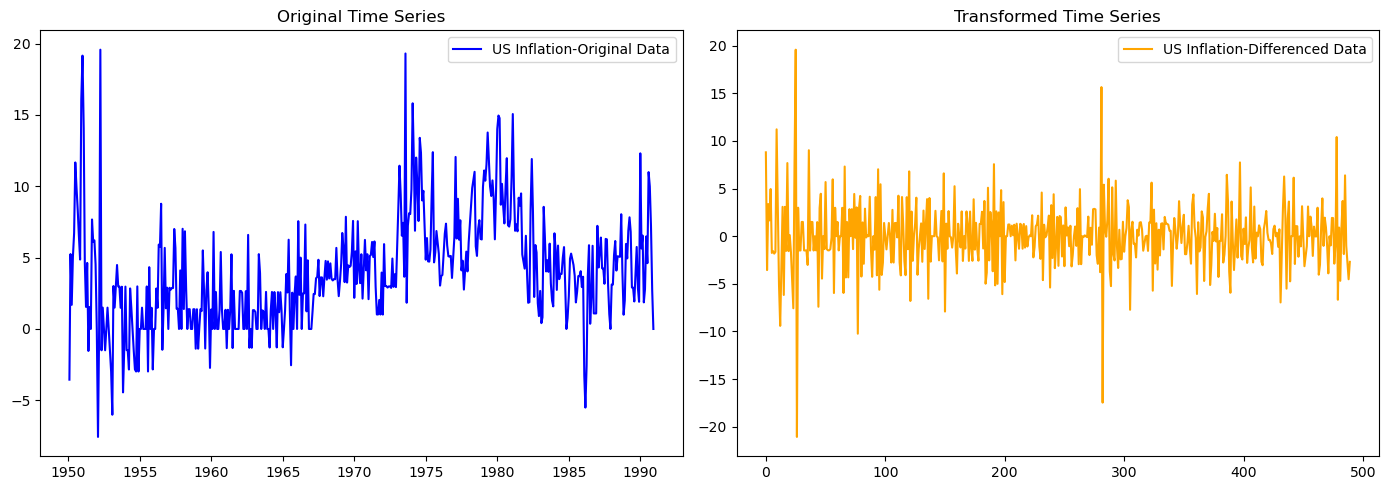

In [30]:
#Plot before and after series
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# original series
axes[0].plot(df, label='US Inflation-Original Data', color='blue')
axes[0].set_title('Original Time Series')
axes[0].legend()

# transformed (differenced) series
axes[1].plot(diff, label='US Inflation-Differenced Data', color='orange')
axes[1].set_title('Transformed Time Series')
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
#The original time series shows clear trends and varying levels, indicating non-stationarity over time.
#After first differencing, the series fluctuates around a constant mean with more stable variance, indicating stationarity.

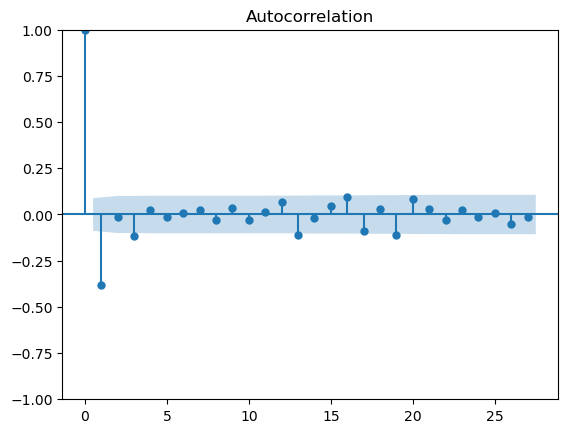

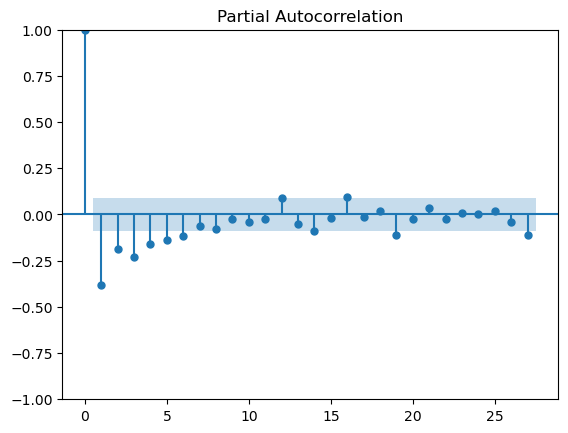

In [32]:
#Find the lag order
plot_acf(diff)
plt.show()

plot_pacf(diff)
plt.show()

In [33]:
#since, the graphs are not that clear we are going for AIC to get the best lag order

In [34]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

orders = [(0,1,1), (1,1,0), (1,1,1), (2,1,1), (0,1,2)]

for order in orders:
    model = ARIMA(train['inflation_1'], order=order)
    result = model.fit()
    print(f"ARIMA{order} → AIC: {result.aic}")

ARIMA(0, 1, 1) → AIC: 1982.6540052236273
ARIMA(1, 1, 0) → AIC: 2044.3534052464315
ARIMA(1, 1, 1) → AIC: 1975.9115288076705
ARIMA(2, 1, 1) → AIC: 1976.9945626702324
ARIMA(0, 1, 2) → AIC: 1977.3356646807006


In [35]:
#Based on AIC comparison, ARIMA(1,1,1) is selected as the best model as it has the lowest AIC value.

In [36]:
#ARIMA Modelling
model=ARIMA(train['inflation_1'],order=(1,1,1))
model_fit=model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            inflation_1   No. Observations:                  392
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -984.956
Date:                Fri, 03 Apr 2026   AIC                           1975.912
Time:                        21:23:39   BIC                           1987.818
Sample:                    02-01-1950   HQIC                          1980.631
                         - 09-01-1982                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1897      0.039      4.890      0.000       0.114       0.266
ma.L1         -0.8603      0.022    -38.856      0.000      -0.904      -0.817
sigma2         9.0036      0.372     24.204      0.0

In [37]:
##coeffiecient interpretations:
# AR(1) coefficient (0.1897) indicates a small positive influence of past values, the MA(1) coefficient (−0.8603) shows a strong negative correction from past errors, and sigma² (9.0036) represents the variance of the residuals

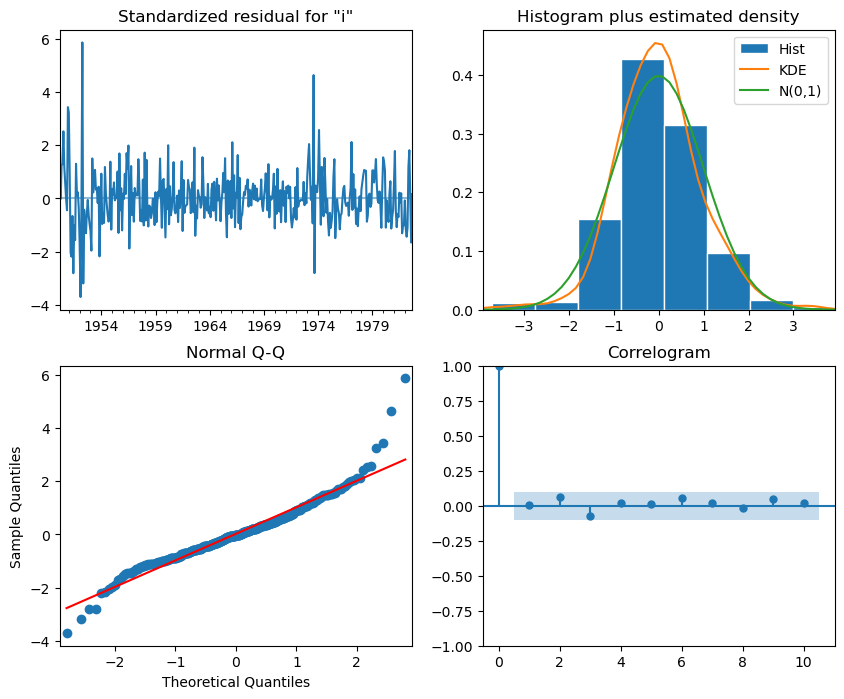

In [38]:
model_fit.plot_diagnostics(figsize=(10,8));

In [39]:
#Overall, the residual diagnostics sggest that the ARIMA(1,1,1) model is adequate, with residuals behaving like white noise.

In [40]:
#ARIMA Forecasting:
forecast = model_fit.forecast(steps=len(test))
test['arima_pred'] = forecast

In [41]:
mae_arima = mean_absolute_error(test['inflation_1'], test['arima_pred'])
mae_arima

2.837046537512523

In [42]:
#Walk Forward Validation:
history = list(train['inflation_1'])
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    obs = test['inflation_1'].iloc[t]

    predictions.append(yhat)
    history.append(obs)

    print(f'Predicted={yhat}, Actual={obs}')

test['wf_pred']=predictions

Predicted=6.165788146994728, Actual=5.358331
Predicted=5.951694554877093, Actual=1.808168
Predicted=4.685930157201201, Actual=0.903063
Predicted=3.945746010226346, Actual=2.664138
Predicted=4.08443094795235, Actual=0.409372
Predicted=3.0813581113579, Actual=0.8182
Predicted=2.791918350334086, Actual=8.558391
Predicted=5.176376126452347, Actual=6.479959
Predicted=4.982133636554902, Actual=4.032262
Predicted=4.365889437525356, Actual=4.820824
Predicted=4.584800432878347, Actual=4.002672
Predicted=4.341982162006195, Actual=5.979086
Predicted=4.9610341732187475, Actual=3.176779
Predicted=4.162258914405188, Actual=1.981179
Predicted=3.61631410490895, Actual=1.582568
Predicted=3.2424260984786386, Actual=6.702875
Predicted=4.735148987176554, Actual=5.491976
Predicted=4.610860275728402, Actual=2.736532
Predicted=3.8088699313619614, Actual=5.843219
Predicted=4.698684910593284, Actual=3.492417
Predicted=4.074322610439996, Actual=3.868475
Predicted=4.116948614138654, Actual=3.856044
Predicted=4.0

In [43]:
# Evaluate the errors
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae_wf = mean_absolute_error(test['inflation_1'], test['wf_pred'])

# RMSE
rmse_wf = np.sqrt(mean_squared_error(test['inflation_1'], test['wf_pred']))

print("Walk-Forward MAE:", mae_wf)
print("Walk-Forward RMSE:", rmse_wf)

Walk-Forward MAE: 2.0033090617743117
Walk-Forward RMSE: 2.6080351677468774


In [44]:
#Sliding Window Forecast:
window_size = len(train)

history = list(train['inflation_1'])
predictions = []

for t in range(len(test)):
    window_data = history[-window_size:]

    model = ARIMA(window_data, order=(1,1,1))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    obs = test['inflation_1'].iloc[t]

    predictions.append(yhat)
    history.append(obs)

    print(f'Predicted={yhat}, Actual={obs}')

test['sw_pred']=predictions

Predicted=6.165788146994728, Actual=5.358331
Predicted=5.94327228115367, Actual=1.808168
Predicted=4.697867655221836, Actual=0.903063
Predicted=3.943438605469054, Actual=2.664138
Predicted=4.0114354218659996, Actual=0.409372
Predicted=3.009654534345659, Actual=0.8182
Predicted=2.7340808692843908, Actual=8.558391
Predicted=5.025860319062796, Actual=6.479959
Predicted=4.920710829566785, Actual=4.032262
Predicted=4.349086019878784, Actual=4.820824
Predicted=4.536197725633888, Actual=4.002672
Predicted=4.333765472258877, Actual=5.979086
Predicted=4.823400588260437, Actual=3.176779
Predicted=4.284072971497121, Actual=1.981179
Predicted=3.8169964053387684, Actual=1.582568
Predicted=3.436367802768719, Actual=6.702875
Predicted=4.484945201771497, Actual=5.491976
Predicted=4.490906953892169, Actual=2.736532
Predicted=3.9375705760873285, Actual=5.843219
Predicted=4.54845572834876, Actual=3.492417
Predicted=4.144751801881582, Actual=3.868475
Predicted=4.144171125796929, Actual=3.856044
Predicted=

In [45]:
# MAE
mae_sw = mean_absolute_error(test['inflation_1'], test['sw_pred'])

# RMSE
rmse_sw = np.sqrt(mean_squared_error(test['inflation_1'], test['sw_pred']))

print("Sliding Window MAE:", mae_sw)
print("Sliding Window RMSE:", rmse_sw)

Sliding Window MAE: 2.031060818132973
Sliding Window RMSE: 2.644364969205422


In [46]:
print("Historical Mean MAE:", mae_hist_mean)
print("Last Value MAE:", mae_last)
print("ARIMA MAE:", mae_arima)
print("Walk-forward MAE:", mae_wf)
print("Sliding Window MAE:", mae_sw)

Historical Mean MAE: 2.046072067279942
Last Value MAE: 2.6158777676767677
ARIMA MAE: 2.837046537512523
Walk-forward MAE: 2.0033090617743117
Sliding Window MAE: 2.031060818132973


In [47]:
#Among all models, walk-forward validation provides the most accurate forecasts with the lowest MAE, outperforming ARIMA and baseline models, indicating that updating the model with new observations improves forecasting performance.

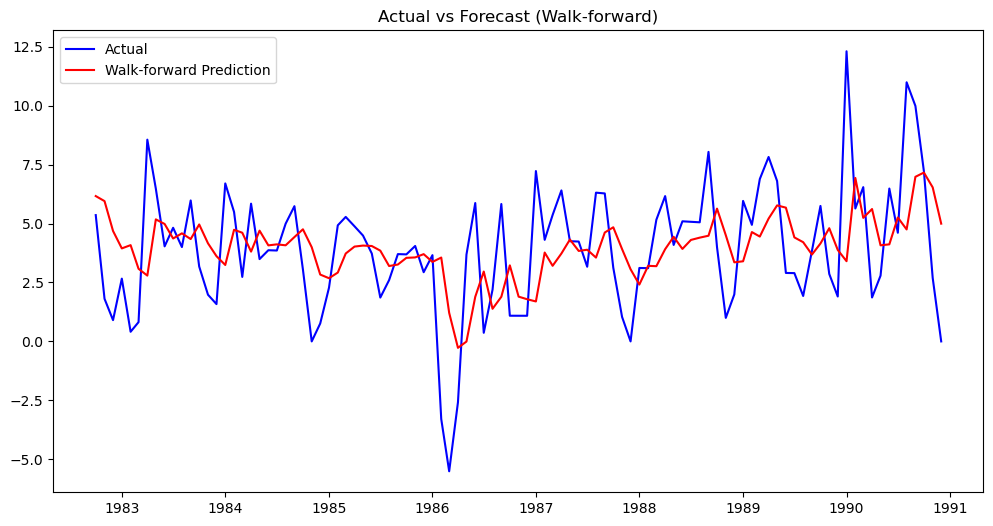

In [48]:
plt.figure(figsize=(12,6))
plt.plot(test['inflation_1'], label='Actual', color='blue')
plt.plot(test['wf_pred'], label='Walk-forward Prediction', color='red')

plt.title("Actual vs Forecast (Walk-forward)")
plt.legend()
plt.show()

In [49]:
#The walk-forward predictions closely follow the actual values, capturing the overall trend and fluctuations, although some deviations occur during sharp spikes.
#This indicates that the model performs well in general but slightly underestimates extreme variations.

#Overall, the walk-forward model provides a good fit, as the predicted values track the actual series reasonably well over time.

In [50]:
##Conclusion:
#The project shows that the inflation series is non-stationary and requires differencing before modeling. While baseline models provide simple benchmarks, ARIMA models perform better in capturing patterns in the data. Among all approaches, walk-forward validation gives the most accurate forecasts, making it the most reliable method for this analysis.